In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
from sklearn import metrics
from sklearn.metrics import precision_score, roc_auc_score

import seaborn as sns


In [2]:
main_unique = pd.read_csv('input_data/3_ML_outputs/datasets/PredictingSLResistanceFeatures_main_withfeatures_dropna_remove_duplicate.csv')
main_unique

/var/folders/cs/dzdz0ppx7lld40ztphtqg_dh0000gp/T/ipykernel_36077/3734827296.py:1: DtypeWarning: Columns (5,16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  main_unique = pd.read_csv('input_data/3_ML_outputs/datasets/PredictingSLResistanceFeatures_main_withfeatures_dropna_remove_duplicate.csv')


,Screen,SL_Pair,Query,Biomarker,Target1,Target2,entrez_id_query,hgnc_id_query,ensembl_gene_id_query,entrez_id_biomarker,...,FET_SharedInteractors_Biomarker_STRING,FET_SharedInteractors_Target_STRING,ExpressionVariance,EssentialityVariance,EssentialityAverage,BIOGRIDPhysicalInteractionQueryBiomarker,BIOGRIDPhysicalInteractionQueryTarget,BiomarkerType,Essentiality_Percentage,Class_Processed
0,Dunn,PTEN_PIK3CB,PIK3R2,PTEN,PIK3CB,NaN,5296.0,HGNC:8980,ENSG00000105647,5728.0,...,114.152228,323.306215,291.159967,0.019359,0.131894,1,1,1,0.509338,1
1,Dunn,PTEN_PIK3CB,INPPL1,PTEN,PIK3CB,NaN,3636.0,HGNC:6080,ENSG00000165458,5728.0,...,34.068956,83.017283,1666.329823,0.019238,-0.020458,0,0,1,0.000000,1
2,Dunn,PTEN_PIK3CB,TSC2,PTEN,PIK3CB,NaN,7249.0,HGNC:12363,ENSG00000103197,5728.0,...,144.356054,62.190596,533.850119,0.194427,0.089340,0,0,1,11.629881,1
3,Dunn,PTEN_PIK3CB,NF2,PTEN,PIK3CB,NaN,4771.0,HGNC:7773,ENSG00000186575,5728.0,...,68.669701,34.650616,46.175986,0.155817,-0.340644,0,0,1,1.103565,1
4,Dunn,PTEN_PIK3CB,CXorf56,PTEN,PIK3CB,NaN,63932.0,HGNC:26239,ENSG00000018610,5728.0,...,-0.097172,-0.188936,45.769746,0.074343,0.205940,0,0,1,8.064516,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142977,Hayes_Krall,NRAS_MEK,ZYG11A,NRAS,MEK1,MEK2,440590.0,HGNC:32058,ENSG00000203995,4893.0,...,0.000000,0.000000,2.097155,0.009856,0.053250,0,0,0,0.000000,0
142978,Hayes_Krall,NRAS_MEK,ZYG11B,NRAS,MEK1,MEK2,79699.0,HGNC:25820,ENSG00000162378,4893.0,...,-0.202768,0.000000,102.933050,0.016370,0.145534,0,0,0,0.424448,0
142979,Hayes_Krall,NRAS_MEK,ZYX,NRAS,MEK1,MEK2,7791.0,HGNC:13200,ENSG00000159840,4893.0,...,9.351460,16.005291,73339.950606,0.016416,0.040647,0,0,0,0.000000,0
142980,Hayes_Krall,NRAS_MEK,ZZEF1,NRAS,MEK1,MEK2,23140.0,HGNC:29027,ENSG00000074755,4893.0,...,-0.203459,0.000000,102.379095,0.014429,0.132027,0,0,0,0.084890,0


# Boxplot (Fig 4B)

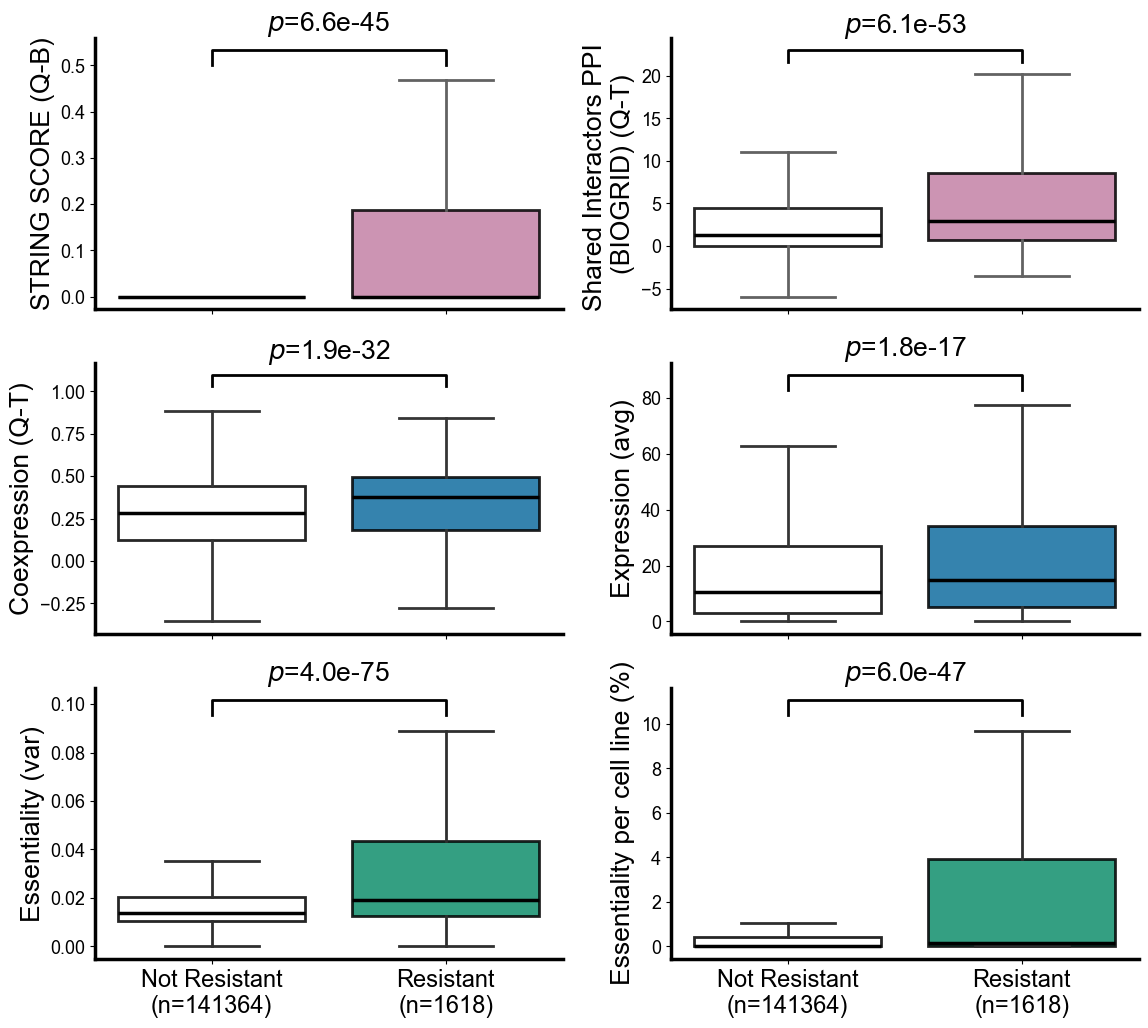

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import math
import warnings
import pingouin as pg
warnings.filterwarnings("ignore")


# === Inputs ===
box_feature = [
    'StringInteractionWithBiomarker',
    'FET_SharedInteractors_Target_BIOGRID',
    'CoexpressionWithTarget',
    'AvgExpression',
    'EssentialityVariance',
    'Essentiality_Percentage'
]

box_labels = [
    'STRING SCORE (Q-B)',
    'Shared Interactors PPI \n(BIOGRID) (Q-T)',
    'Coexpression (Q-T)',
    'Expression (avg)',
    'Essentiality (var)',
    'Essentiality per cell line (%)'
]

# === Feature groups and color mapping ===
group_color_mapping = {
    'STRING': '#CC79A7',       
    'PPI': '#CC79A7',          # bright pink (PPI/STRING)
    'coexpression': '#0072B2', # dark blue
    'expression': '#0072B2',   # dark blue
    'essentiality': '#009E73'  # dark green
}

feature_groups = {
    'StringInteractionWithBiomarker': 'STRING',
    'StringInteractionWithTarget': 'STRING',
    'FET_SharedInteractors_Biomarker_BIOGRID': 'PPI',
    'FET_SharedInteractors_Target_BIOGRID': 'PPI',
    'FET_SharedInteractors_Biomarker_STRING': 'PPI',
    'FET_SharedInteractors_Target_STRING': 'PPI',
    'CoexpressionWithBiomarker': 'coexpression',
    'CoexpressionWithTarget': 'coexpression',
    'CoessentialityWithBiomarker': 'essentiality',
    'CoessentialityWithTarget': 'essentiality',
    'EssentialityVariance': 'essentiality',
    'EssentialityAverage': 'essentiality',
    'AvgExpression': 'expression',
    'ExpressionVariance': 'expression',
    'Essentiality_Percentage': 'essentiality'
}
color_mapping = {
    feat: group_color_mapping[feature_groups[feat]]
    for feat in box_feature
}

target_column = 'Class_Processed'
df = main_unique  # <-- ensure defined upstream

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

# === Utility Functions ===

def compute_upper_whisker(df_sub, feature):
    Q1 = df_sub[feature].quantile(0.25)
    Q3 = df_sub[feature].quantile(0.75)
    IQR = Q3 - Q1
    return Q3 + 1.5 * IQR

def draw_signif_line(ax, x0, x1, y, pval, hd=15):
    """Draws a significance bar with only the p-value (no CLES)."""
    h = y / hd
    p_text = '$p$=%.1e' % pval if pval < 0.0001 else '$p$=%.4f' % pval
    ax.plot([x0, x0, x1, x1],
            [y + h, y + 2*h, y + 2*h, y + h],
            lw=2.0, c='black')   # <--- increase thickness here
    ax.text((x0 + x1) * 0.5, y + 2.8 * h, p_text,
            ha='center', va='bottom', fontsize=19, color='black')


def draw_cont_graph(df, feature, target_column, ax, label=None, hd=15):
    true_color = color_mapping.get(feature, '#8491B4FF')
    my_pal = {0: "white", 1: true_color}

    count_0 = (df[target_column] == 0).sum()
    count_1 = (df[target_column] == 1).sum()

    sns.despine(ax=ax)
    sns.boxplot(
    x=target_column, y=feature, data=df,
    ax=ax, palette=my_pal,
    linewidth=2.0,               # <--- thicker whiskers + box edges
    saturation=0.8,
    showfliers=False, showmeans=False, order=[0, 1],
    medianprops={'color': 'black', 'linewidth': 2.5},  # thicker median line
    boxprops={'edgecolor': 'black', 'alpha': 0.85, 'linewidth': 2.0},  # thicker box edges
    whiskerprops={'linewidth': 2.0},   # <--- thicker whiskers
    capprops={'linewidth': 2.0}        # <--- thicker caps
)

    ax.set_ylabel(label if label else feature, fontsize=19)
    ax.set_xlabel('', fontsize=15)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(
        [f'Not Resistant\n(n={count_0})', f'Resistant\n(n={count_1})'],
        fontsize=17
    )
    ax.tick_params(axis='y', labelsize=13)

    # === Thicken spines (backbone) ===
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)

    # === Mann–Whitney U test (two-sided) ===
    group0 = df[df[target_column] == 0][feature]
    group1 = df[df[target_column] == 1][feature]
    result = pg.mwu(group0, group1, alternative='two-sided')
    pval = result['p-val'].values[0]

    upper_whisker = max(
        compute_upper_whisker(df[df[target_column] == 0], feature),
        compute_upper_whisker(df[df[target_column] == 1], feature)
    )
    draw_signif_line(ax, 0, 1, upper_whisker, pval, hd)


# === Plotting ===

n_features = len(box_feature)
n_cols = 2
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.8 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(box_feature):
    ax = axes[i]
    draw_cont_graph(df, feature, target_column, ax=ax, label=box_labels[i])

    # Hide xticklabels for all but the bottom row
    row = i // n_cols
    if row < n_rows - 1:   # if not last row
        ax.set_xticklabels([])
        ax.set_xlabel("")

# Remove any unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=1.5)
fig.savefig("results/5_ML_graphs/figure_4b_boxplot_group_colored_features_selectedfeatures.png",
            dpi=600, bbox_inches='tight')
plt.show()



# Fig S5

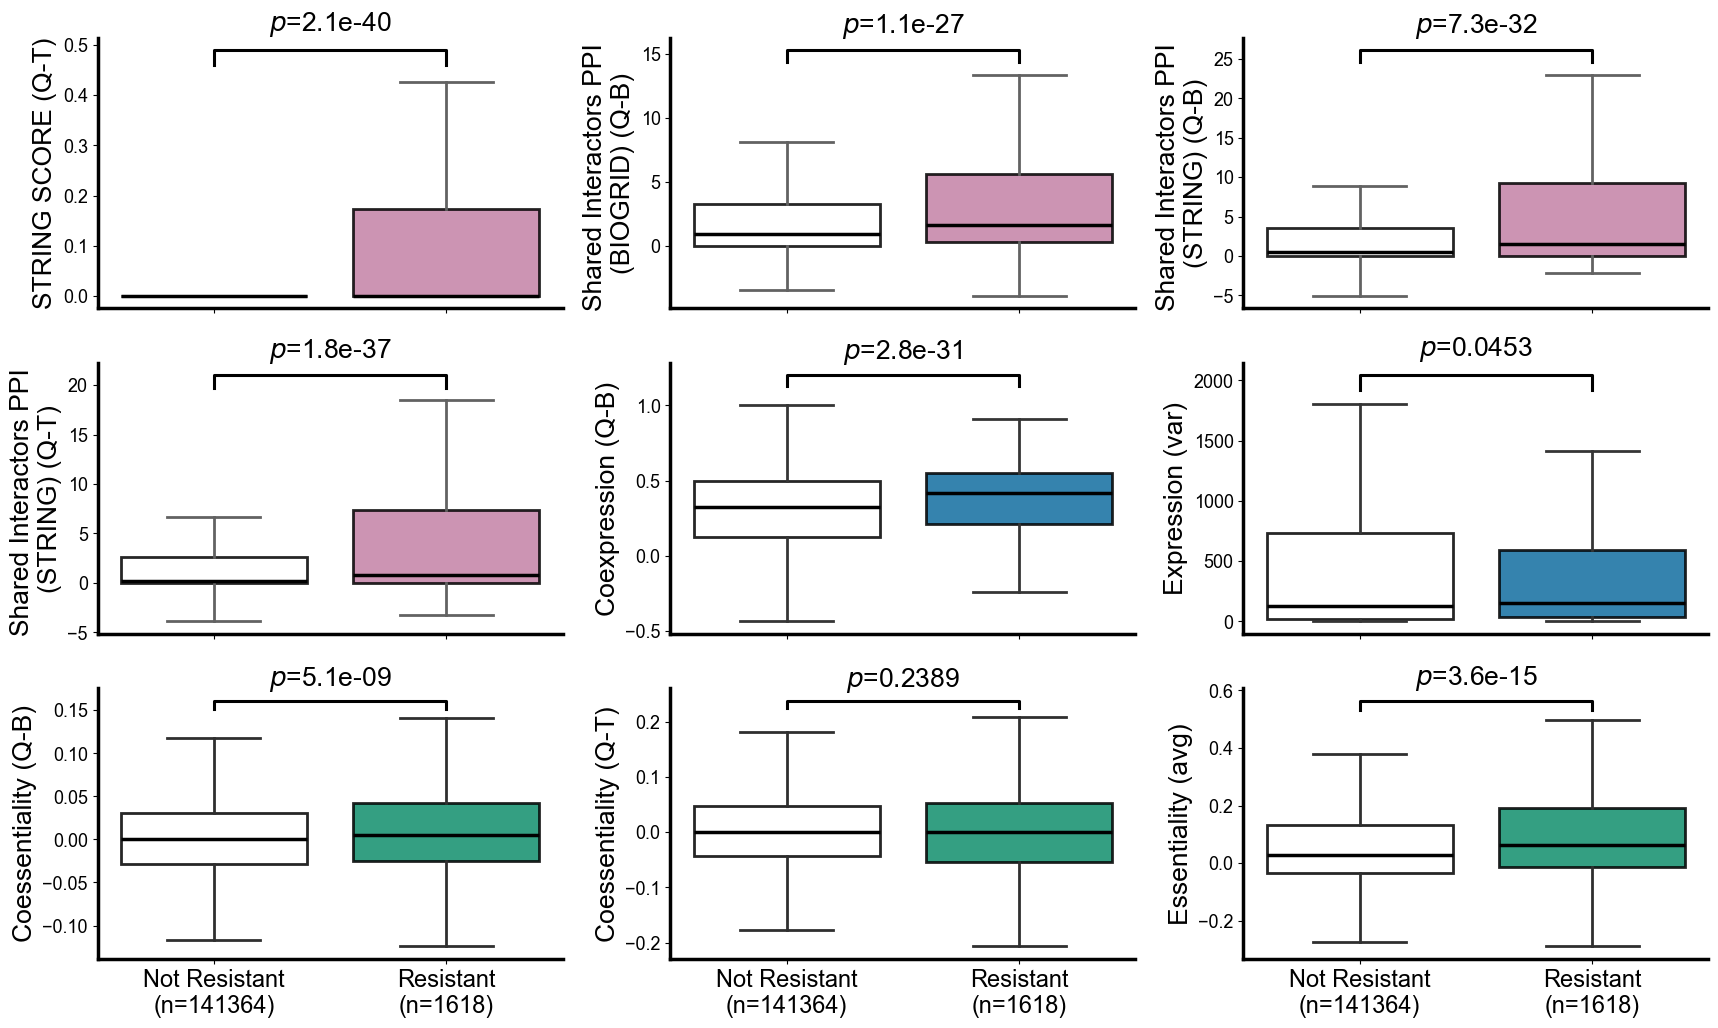

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math
import warnings
import pingouin as pg
warnings.filterwarnings("ignore")

# === Inputs ===
box_feature = [
    'StringInteractionWithTarget',
    'FET_SharedInteractors_Biomarker_BIOGRID',
    'FET_SharedInteractors_Biomarker_STRING',
    'FET_SharedInteractors_Target_STRING',
    'CoexpressionWithBiomarker',
    'ExpressionVariance',
    'CoessentialityWithBiomarker',
    'CoessentialityWithTarget',
    'EssentialityAverage'
]

box_labels = [
    'STRING SCORE (Q-T)',
    'Shared Interactors PPI \n(BIOGRID) (Q-B)',
    'Shared Interactors PPI \n(STRING) (Q-B)',
    'Shared Interactors PPI \n(STRING) (Q-T)',
    'Coexpression (Q-B)',
    'Expression (var)',
    'Coessentiality (Q-B)',
    'Coessentiality (Q-T)',
    'Essentiality (avg)'
]

# === Feature groups and color mapping ===
group_color_mapping = {
    'STRING': '#CC79A7',
    'PPI': '#CC79A7',
    'coexpression': '#0072B2',
    'expression': '#0072B2',
    'essentiality': '#009E73'
}

feature_groups = {
    'StringInteractionWithBiomarker': 'STRING',
    'StringInteractionWithTarget': 'STRING',
    'FET_SharedInteractors_Biomarker_BIOGRID': 'PPI',
    'FET_SharedInteractors_Target_BIOGRID': 'PPI',
    'FET_SharedInteractors_Biomarker_STRING': 'PPI',
    'FET_SharedInteractors_Target_STRING': 'PPI',
    'CoexpressionWithBiomarker': 'coexpression',
    'CoexpressionWithTarget': 'coexpression',
    'CoessentialityWithBiomarker': 'essentiality',
    'CoessentialityWithTarget': 'essentiality',
    'EssentialityVariance': 'essentiality',
    'EssentialityAverage': 'essentiality',
    'AvgExpression': 'expression',
    'ExpressionVariance': 'expression',
    'Essentiality_Percentage': 'essentiality'
}

color_mapping = {feat: group_color_mapping[feature_groups[feat]]
                 for feat in box_feature}

target_column = 'Class_Processed'
df = main_unique  # <-- make sure defined upstream

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

# === Utility Functions ===
def compute_upper_whisker(df_sub, feature):
    Q1 = df_sub[feature].quantile(0.25)
    Q3 = df_sub[feature].quantile(0.75)
    IQR = Q3 - Q1
    return Q3 + 1.5 * IQR

def draw_signif_line(ax, x0, x1, y, pval, hd=15):
    """Draws a significance bar with p-value annotation."""
    h = y / hd
    p_text = '$p$=%.1e' % pval if pval < 0.0001 else '$p$=%.4f' % pval
    ax.plot([x0, x0, x1, x1],
            [y + h, y + 2*h, y + 2*h, y + h],
            lw=2.2, c='black')   # <--- thicker p-value line
    ax.text((x0 + x1) * 0.5,
            y + 2.8 * h,
            p_text,
            ha='center', va='bottom',
            fontsize=19, color='black')  # <--- bold p-value text

def draw_cont_graph(df, feature, target_column, ax, label=None, hd=15):
    true_color = color_mapping.get(feature, '#8491B4FF')
    my_pal = {0: "white", 1: true_color}

    count_0 = (df[target_column] == 0).sum()
    count_1 = (df[target_column] == 1).sum()

    sns.despine(ax=ax)
    sns.boxplot(
        x=target_column, y=feature, data=df,
        ax=ax, palette=my_pal,
        linewidth=2.0,                # <--- thicker edges
        saturation=0.8,
        showfliers=False, showmeans=False, order=[0, 1],
        medianprops={'color': 'black', 'linewidth': 2.5},  # <--- thicker median line
        boxprops={'edgecolor': 'black', 'alpha': 0.85, 'linewidth': 2.0}, # <--- thicker box edges
        whiskerprops={'linewidth': 2.0},   # <--- thicker whiskers
        capprops={'linewidth': 2.0}        # <--- thicker caps
    )

    ax.set_ylabel(label if label else feature, fontsize=19)
    ax.set_xlabel('', fontsize=15)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(
        [f'Not Resistant\n(n={count_0})', f'Resistant\n(n={count_1})'],
        fontsize=17
    )
    ax.tick_params(axis='y', labelsize=13)

    # === Thicken spines (backbone) ===
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)

    # === Mann–Whitney U test ===
    group0 = df[df[target_column] == 0][feature]
    group1 = df[df[target_column] == 1][feature]
    result = pg.mwu(group0, group1, alternative='two-sided')
    pval = result['p-val'].values[0]

    upper_whisker = max(
        compute_upper_whisker(df[df[target_column] == 0], feature),
        compute_upper_whisker(df[df[target_column] == 1], feature)
    )
    draw_signif_line(ax, 0, 1, upper_whisker, pval, hd)

# === Plotting ===
n_features = len(box_feature)
n_cols = 3
n_rows = 3   # since you have exactly 9 features

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(5.8 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(box_feature):
    ax = axes[i]
    draw_cont_graph(df, feature, target_column, ax=ax, label=box_labels[i])

    # Hide xticklabels for all but bottom row
    row = i // n_cols
    if row < n_rows - 1:  # if not last row
        ax.set_xticklabels([])
        ax.set_xlabel("")

# Remove any unused axes (not needed here, exactly 9 features = 3x3 grid)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=1.5)
fig.savefig("results/5_ML_graphs/figure_5S_boxplot_group_colored_other_features.png",
            dpi=600, bbox_inches='tight')
plt.show()



# Fig 4a

/Users/metinyazar/anaconda3/envs/main/lib/python3.12/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/metinyazar/anaconda3/envs/main/lib/python3.12/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/metinyazar/anaconda3/envs/main/lib/python3.12/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/metinyazar/anaconda3/envs/main/lib/python3.12/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be remov

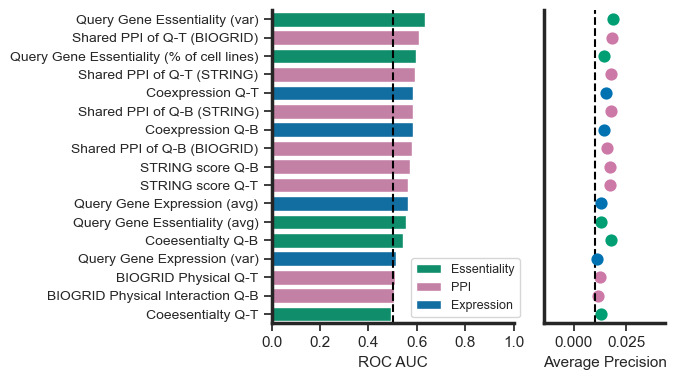

In [ ]:
# Define feature metadata using a dictionary
features_dict = [
    {"name": "StringInteractionWithBiomarker", "label": "STRING score Q-B", "category": "PPI"},
    {"name": "StringInteractionWithTarget", "label": "STRING score Q-T", "category": "PPI"},
    {"name": "CoexpressionWithBiomarker", "label": "Coexpression Q-B", "category": "Expression"},
    {"name": "CoexpressionWithTarget", "label": "Coexpression Q-T","category": "Expression"},
    {"name": "AvgExpression", "label": "Query Gene Expression (avg)","category": "Expression"},
    {"name": "CoessentialityWithBiomarker", "label": "Coeesentialty Q-B","category": "Essentiality"},
    {"name": "CoessentialityWithTarget", "label": "Coeesentialty Q-T","category": "Essentiality"},
    {"name": "FET_SharedInteractors_Biomarker_BIOGRID", "label": "Shared PPI of Q-B (BIOGRID)","category": "PPI"},
    {"name": "FET_SharedInteractors_Target_BIOGRID", "label": "Shared PPI of Q-T (BIOGRID)","category": "PPI"},
    {"name": "FET_SharedInteractors_Biomarker_STRING", "label": "Shared PPI of Q-B (STRING)","category": "PPI"},
    {"name": "FET_SharedInteractors_Target_STRING", "label": "Shared PPI of Q-T (STRING)","category": "PPI"},
    {"name": "BIOGRIDPhysicalInteractionQueryBiomarker", "label": "BIOGRID Physical Interaction Q-B","category": "PPI"},
    {"name": "BIOGRIDPhysicalInteractionQueryTarget", "label": "BIOGRID Physical Q-T","category": "PPI"},
    {"name": "ExpressionVariance", "label": "Query Gene Expression (var)","category": "Expression"},
    {"name": "EssentialityVariance", "label": "Query Gene Essentiality (var)","category": "Essentiality"},
    {"name": "EssentialityAverage", "label": "Query Gene Essentiality (avg)","category": "Essentiality"},
    {"name": "Essentiality_Percentage", "label": "Query Gene Essentiality (% of cell lines)","category": "Essentiality"}
]

# Extract specific information dynamically if needed
feature_columns = [f["name"] for f in features_dict]
labels = [f["label"] for f in features_dict]
categories = [f["category"] for f in features_dict]

# Target column
target_column = "Class_Processed"

import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score

def compute_predictive_feature_scores(dataframe, target_column, feature_columns, features_metadata):
    """
    Computes ROC AUC and Average Precision scores for given features and adds labels and categories.
    
    Parameters:
    dataframe (pd.DataFrame): The input DataFrame containing features and target.
    target_column (str): The name of the target column.
    feature_columns (list): List of feature column names to evaluate.
    features_metadata (list): List of dictionaries containing feature name, label, and category.

    Returns:
    pd.DataFrame: DataFrame containing feature-wise ROC AUC, Average Precision, labels, and categories.
    """
    X = dataframe[feature_columns]
    y = dataframe[target_column]

    feature_scores = {}

    for feature in X.columns:
        roc_auc = roc_auc_score(y, X[feature])
        avg_precision = average_precision_score(y, X[feature])
        feature_scores[feature] = {
            "ROC AUC Score": roc_auc,
            "Average Precision": avg_precision
        }

    # Convert to DataFrame
    score_df = pd.DataFrame.from_dict(feature_scores, orient="index").reset_index()
    score_df.columns = ["Feature", "ROC AUC Score", "Average Precision"]

    # Sort by ROC AUC score
    score_df = score_df.sort_values(by="ROC AUC Score", ascending=False).reset_index(drop=True)

    # Convert metadata to a DataFrame
    metadata_df = pd.DataFrame(features_metadata)

    # Merge feature scores with metadata on "Feature" name
    final_df = score_df.merge(metadata_df, left_on="Feature", right_on="name", how="left").drop(columns=["name"])

    return final_df

pred_features = compute_predictive_feature_scores(main_unique, target_column, feature_columns, features_dict)
def plot_roc_pr(pred_df):
    sns.set_theme(style="ticks")

    # Bigger figure and better aspect
    f, ax = plt.subplots(ncols=2, nrows=1, figsize=(7, 4), sharey=True, gridspec_kw={'width_ratios': [2, 1]})
    
    colors = ["#009E73", "#CC79A7","#0072B2",]
    plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'pdf.fonttype': 42,  # Ensure vector fonts for PDF
    'ps.fonttype': 42})


    # ROC AUC barplot
    sns.barplot(
        data=pred_df,
        x='ROC AUC Score',
        y='label',
        hue='category',
        palette=colors,
        saturation=0.8,
        dodge=False,
        ax=ax[0]
    )
    ax[0].set_xlabel('ROC AUC', fontsize=11) 
    ax[0].set_ylabel('')
    ax[0].set_xlim(0, 1)
    ax[0].tick_params('x', labelsize=11)
    ax[0].tick_params('y', labelsize=10)
    ax[0].axvline(x=0.5, linestyle='--', color='black')
    ax[0].legend(loc='lower right', fontsize=9, title_fontsize=9, bbox_to_anchor=(1.05, 0))

    # Average Precision pointplot
    sns.pointplot(
        data=pred_df,
        x='Average Precision',
        y='label',
        hue='category',
        palette=colors,
        dodge=False,
        markers='o',
        linestyles='none',
        errorbar=None,
        ax=ax[1]
    )

    # Increase marker size
    for line in ax[1].lines:
        line.set_markersize(6)

    ax[1].set_xlabel('Average Precision', fontsize=11) 
    ax[1].set_ylabel('')
    ax[1].set_xlim(pred_df['Average Precision'].min() - 0.025, pred_df['Average Precision'].max() + 0.025)
    ax[1].tick_params('x', labelsize=11)
    ax[1].tick_params('y', left=False, labelleft=False)
    ax[1].axvline(x=no_skill, linestyle='--', color='black')
    ax[1].legend().remove()

    # Remove top and right borders
    sns.despine(ax=ax[0], top=True, right=True)
    sns.despine(ax=ax[1], top=True, right=True)
    # === Thicken backbones (spines) ===
    for ax_i in ax:
        for spine in ax_i.spines.values():
            spine.set_linewidth(2.5)   # <-- adjust thickness here


    plt.tight_layout(pad=1.2)
    plt.savefig("results/5_ML_graphs/figure_4a_predictive_power_features.png", dpi=600, bbox_inches='tight')
    plt.show()

no_skill = round(sum(main_unique['Class_Processed']) / len(main_unique['Class_Processed']), 2)

plot_roc_pr(pred_features)

# Random Forest with random train-test split

# Fig 5A

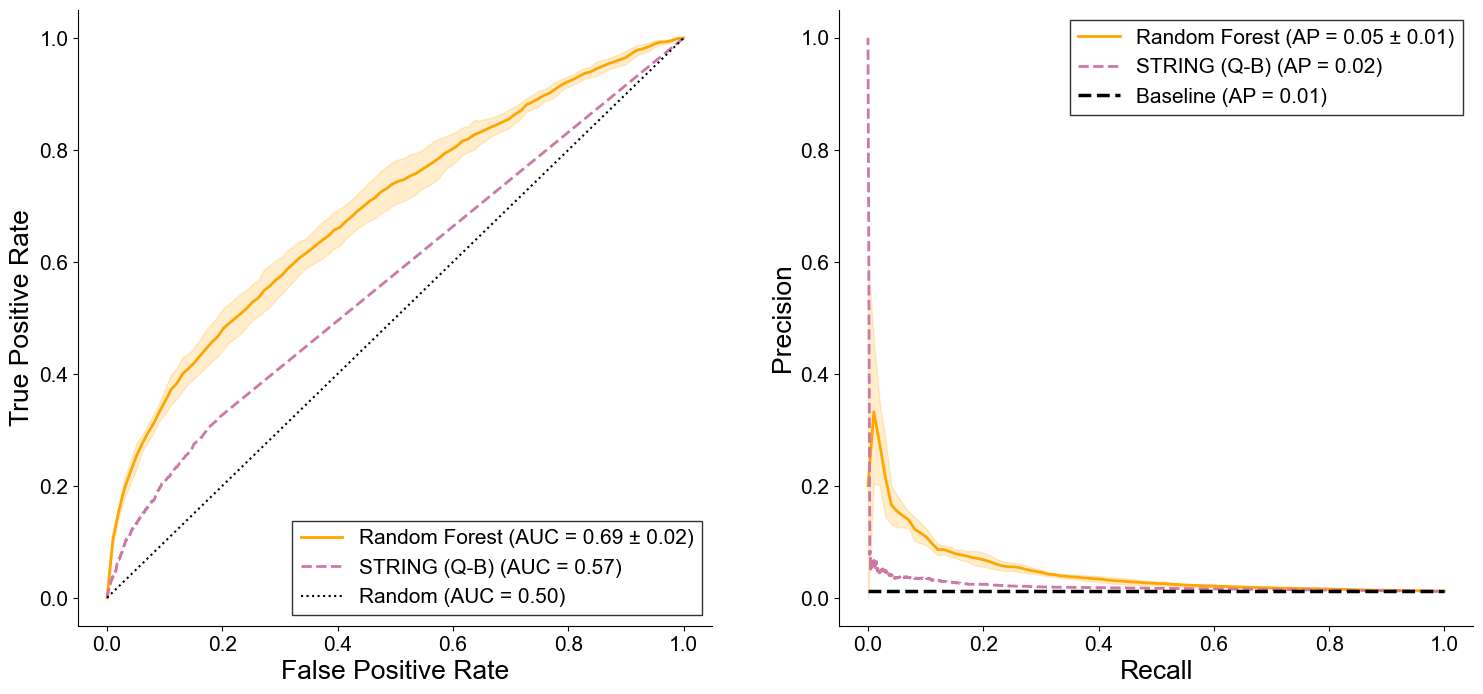

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, precision_recall_curve,
    average_precision_score, roc_auc_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
import numpy as np

# === Feature selection ===
string_feature_name = 'StringInteractionWithBiomarker'

# === Prepare data ===
X = main_unique.iloc[:, -19:-1].values
y = main_unique['Class_Processed'].values
x_string = main_unique[string_feature_name].values

# === Cross-validation setup ===
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store results for folds
tprs, aucs = [], []
precisions, aps = [], []
mean_fpr = np.linspace(0, 1, 100)
mean_recall = np.linspace(0, 1, 100)

rf = RandomForestClassifier(
    n_estimators=1000, max_features=1, max_depth=15,
    min_samples_leaf=4, random_state=42
)

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    rf.fit(X_train, y_train)
    y_prob = rf.predict_proba(X_test)[:, 1]

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(roc_auc_score(y_test, y_prob))

    # PR
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    interp_prec = np.interp(mean_recall, recall[::-1], precision[::-1])  # need increasing x
    precisions.append(interp_prec)
    aps.append(average_precision_score(y_test, y_prob))

# === Average curves ===
mean_tpr = np.mean(tprs, axis=0)
std_tpr = np.std(tprs, axis=0)
mean_auc = np.mean(aucs)
std_auc = np.std(aucs)

mean_prec = np.mean(precisions, axis=0)
std_prec = np.std(precisions, axis=0)
mean_ap = np.mean(aps)
std_ap = np.std(aps)

# === Baseline precision ===
baseline_precision = y.mean()

# === External STRING and Coexpression performance ===
fpr_string, tpr_string, _ = roc_curve(y, x_string)
precision_string, recall_string, _ = precision_recall_curve(y, x_string)
auc_string = roc_auc_score(y, x_string)
ap_string = average_precision_score(y, x_string)

# === Plot ===
plt.figure(figsize=(18, 8))
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

# --- ROC ---
plt.subplot(1, 2, 1)
plt.plot(mean_fpr, mean_tpr, color='orange',
         label=f"Random Forest (AUC = {mean_auc:.2f} ± {std_auc:.2f})",
         lw=2)
plt.fill_between(mean_fpr,
                 mean_tpr - std_tpr,
                 mean_tpr + std_tpr,
                 color='orange', alpha=0.2)

plt.plot(fpr_string, tpr_string, '--', color='#CC79A7',
         label=f"STRING (Q-B) (AUC = {auc_string:.2f})", lw=2)
plt.plot([0, 1], [0, 1], linestyle=':', color='black',
         label="Random (AUC = 0.50)", lw=1.5)

plt.xlabel("False Positive Rate", fontsize=19)
plt.ylabel("True Positive Rate", fontsize=19)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(loc="lower right", fontsize=15,
           frameon=True, edgecolor='black', fancybox=False)
plt.grid(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
# --- PR ---
plt.subplot(1, 2, 2)
plt.plot(mean_recall, mean_prec, color='orange',
         label=f"Random Forest (AP = {mean_ap:.2f} ± {std_ap:.2f})", lw=2)

# Clip the lower and upper bounds to stay within [0, 1]
lower = np.clip(mean_prec - std_prec, 0, 1)
upper = np.clip(mean_prec + std_prec, 0, 1)

plt.fill_between(mean_recall, lower, upper,
                 color='orange', alpha=0.2)

plt.plot(recall_string, precision_string, '--', color='#CC79A7',
         label=f"STRING (Q-B) (AP = {ap_string:.2f})", lw=2)
plt.hlines(baseline_precision, 0, 1, linestyle='--', color='black',
           label=f"Baseline (AP = {baseline_precision:.2f})", lw=2.5)

plt.xlabel("Recall", fontsize=19)
plt.ylabel("Precision", fontsize=19)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(loc="upper right", fontsize=15,
           frameon=True, edgecolor='black', fancybox=False)
plt.grid(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.savefig("results/5_ML_graphs/figure_5a_random_forest_random_split.png", dpi=600, bbox_inches='tight')

plt.show()


# ROC curve showing leave one biomarker out evaluation (Fig 5B)

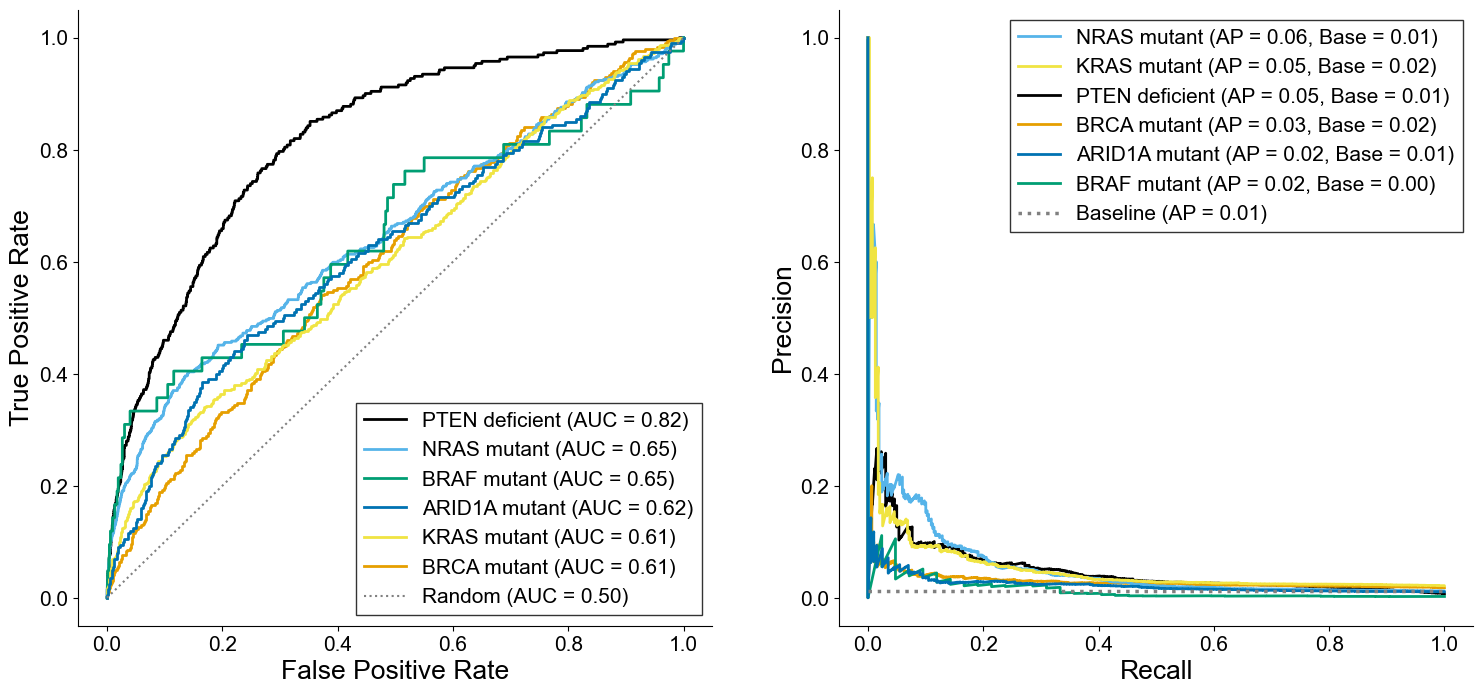

In [ ]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_curve, precision_recall_curve,
    average_precision_score, roc_auc_score
)

def compare_rf_models_by_sl_pair_groups(
    df,
    sl_pair_groups,
    feature_cols,
    target_col='Class_Processed'
):
    plt.figure(figsize=(18, 8))
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial'],
        'pdf.fonttype': 42,
        'ps.fonttype': 42
    })

    # Custom color palette
    color_palette = [
        "#000000", "#E69F00", "#56B4E9", "#009E73",
        "#F0E442", "#0072B2", "#D55E00", "#CC79A7"
    ]

    # Containers for sorting
    roc_handles, roc_labels, roc_aucs = [], [], []
    pr_handles, pr_labels, pr_aps = [], [], []

    for i, (group_label, sl_pairs) in enumerate(sl_pair_groups.items()):
        test_mask = df['SL_Pair'].isin(sl_pairs)
        train_mask = ~test_mask

        train = df[train_mask]
        test = df[test_mask]

        X_train = train[feature_cols]
        X_test = test[feature_cols]
        y_train = train[target_col]
        y_test = test[target_col]

        rf = RandomForestClassifier(
            n_estimators=1000,
            max_features=1,
            max_depth=15,
            min_samples_leaf=4,
            random_state=42
        )
        rf.fit(X_train, y_train)
        y_prob = rf.predict_proba(X_test)[:, 1]

        avg_precision = average_precision_score(y_test, y_prob)
        roc_auc = roc_auc_score(y_test, y_prob)
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        precision, recall, _ = precision_recall_curve(y_test, y_prob)
        baseline_precision = y_test.mean()

        color = color_palette[i % len(color_palette)]

        # Plot ROC but collect handles
        plt.subplot(1, 2, 1)
        (line_roc,) = plt.plot(
            fpr, tpr, color=color, linewidth=2,
            label=f"{group_label} (AUC = {roc_auc:.2f})"
        )
        roc_handles.append(line_roc)
        roc_labels.append(line_roc.get_label())
        roc_aucs.append(roc_auc)

        # Plot PR but collect handles
        plt.subplot(1, 2, 2)
        (line_pr,) = plt.plot(
            recall, precision, color=color, linewidth=2,
            label=f"{group_label} (AP = {avg_precision:.2f}, Base = {baseline_precision:.2f})"
        )
        pr_handles.append(line_pr)
        pr_labels.append(line_pr.get_label())
        pr_aps.append(avg_precision)

    # === ROC formatting ===
    plt.subplot(1, 2, 1)
    line_rand, = plt.plot([0, 1], [0, 1], linestyle=':', color='gray',
                          label="Random (AUC = 0.50)", linewidth=1.5)

    sorted_items = sorted(zip(roc_handles, roc_labels, roc_aucs),
                          key=lambda x: x[2], reverse=True)
    sorted_handles, sorted_labels, _ = zip(*sorted_items)
    plt.legend(list(sorted_handles) + [line_rand],
               list(sorted_labels) + [line_rand.get_label()],
               loc="lower right", fontsize=15,
               frameon=True, edgecolor='black', fancybox=False)

    plt.xlabel("False Positive Rate", fontsize=19)
    plt.ylabel("True Positive Rate", fontsize=19)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.grid(False)
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # === PR formatting ===
    plt.subplot(1, 2, 2)
    overall_baseline = df[target_col].mean()
    line_base = plt.hlines(overall_baseline, 0, 1, linestyle=':', color='gray',
                           label=f"Baseline (AP = {overall_baseline:.2f})", linewidth=2.5)

    sorted_items = sorted(zip(pr_handles, pr_labels, pr_aps),
                          key=lambda x: x[2], reverse=True)
    sorted_handles, sorted_labels, _ = zip(*sorted_items)
    plt.legend(list(sorted_handles) + [line_base],
               list(sorted_labels) + [line_base.get_label()],
               loc="upper right", fontsize=15,
               frameon=True, edgecolor='black', fancybox=False)

    plt.xlabel("Recall", fontsize=19)
    plt.ylabel("Precision", fontsize=19)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.grid(False)
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.savefig("results/5_ML_graphs/figure_5b_roc_pr_leave_one_biomarker_out.png",
                dpi=600, bbox_inches='tight')
    plt.show()


# === Usage ===
feature_columns = main_unique.columns[-19:-1].tolist()

compare_rf_models_by_sl_pair_groups(
    df=main_unique,
    sl_pair_groups={
        "PTEN deficient": ["PTEN_AKT", "PTEN_PIK3CB"],
        "BRCA mutant": ["BRCA1_PARP1"],
        "NRAS mutant": ["NRAS_MEK", "NRAS_CDK4_6"],
        "BRAF mutant": ["BRAF_MEK"],
        "KRAS mutant": ["KRAS_MEK"],
        "ARID1A mutant": ["ARID1A_ATR"]
    },
    feature_cols=feature_columns,
    target_col='Class_Processed'
)


# ROC curve showing leave one target out evaluation (Fig 5C)

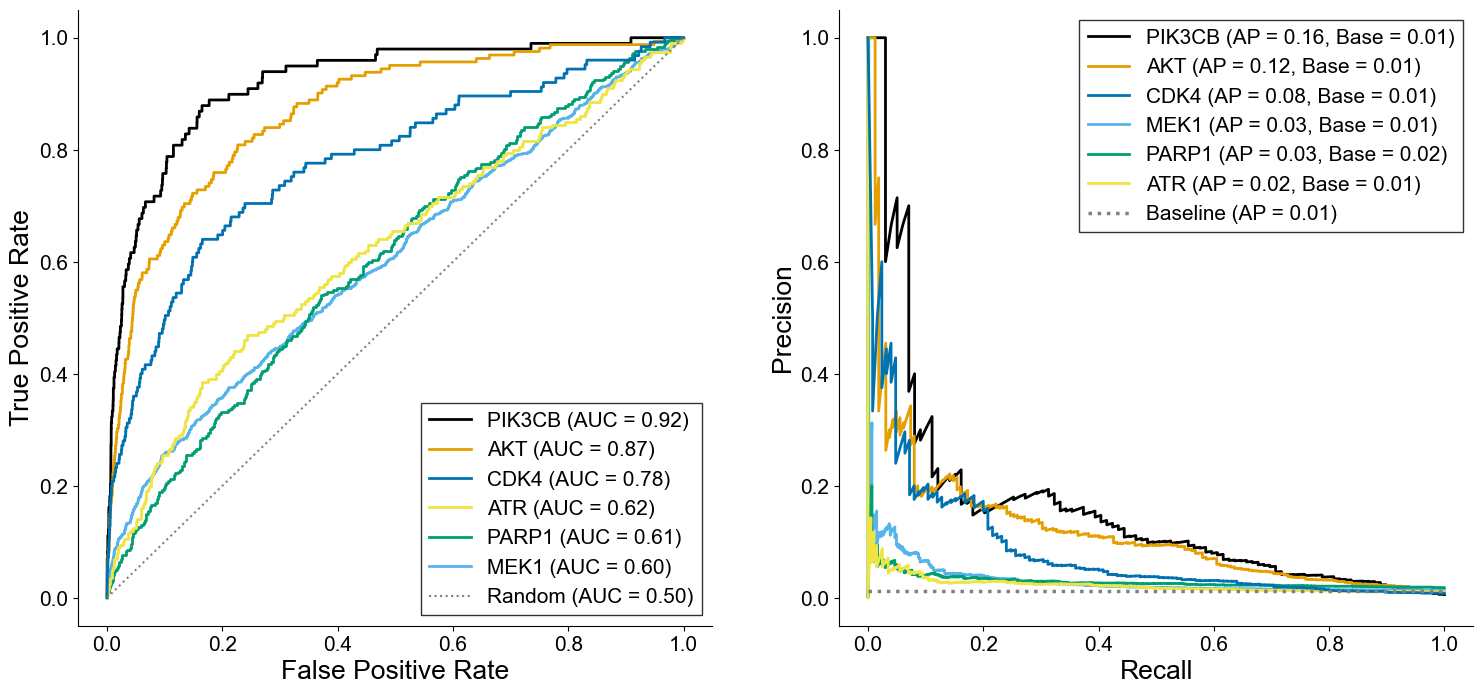

In [ ]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
    confusion_matrix
)
import pandas as pd

def compare_rf_models_by_inhibitors(
    df,
    inhibitors,
    feature_cols,
    target_col='Class_Processed'
):
    """
    Trains and evaluates a Random Forest model for multiple inhibitors.
    Plots ROC and PR curves for all models in one figure, legends sorted by performance.
    """
    colors = [
        '#000000', '#E69F00', '#56B4E9', '#009E73',
        '#F0E442', '#0072B2', '#D55E00', '#CC79A7'
    ]

    plt.figure(figsize=(18, 8))
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial'],
        'pdf.fonttype': 42,
        'ps.fonttype': 42
    })

    # Containers for sorting
    roc_handles, roc_labels, roc_aucs = [], [], []
    pr_handles, pr_labels, pr_aps = [], [], []

    for i, inhibitor in enumerate(inhibitors):
        test_mask = (df['Target1'] == inhibitor)
        train_mask = ~test_mask

        train = df[train_mask]
        test = df[test_mask]

        X_train = train[feature_cols]
        X_test = test[feature_cols]
        y_train = train[target_col]
        y_test = test[target_col]

        rf = RandomForestClassifier(
            n_estimators=1000,
            max_features=1,
            max_depth=15,
            min_samples_leaf=4,
            random_state=42
        )
        rf.fit(X_train, y_train)

        y_pred = rf.predict(X_test)
        y_prob = rf.predict_proba(X_test)[:, 1]

        avg_precision = average_precision_score(y_test, y_prob)
        roc_auc = roc_auc_score(y_test, y_prob)
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        precision, recall, _ = precision_recall_curve(y_test, y_prob)
        baseline_precision = y_test.mean()

        color = colors[i % len(colors)]

        # Plot ROC but collect handles
        plt.subplot(1, 2, 1)
        (line_roc,) = plt.plot(
            fpr, tpr,
            label=f"{inhibitor} (AUC = {roc_auc:.2f})",
            linewidth=2, color=color
        )
        roc_handles.append(line_roc)
        roc_labels.append(line_roc.get_label())
        roc_aucs.append(roc_auc)

        # Plot PR but collect handles
        plt.subplot(1, 2, 2)
        (line_pr,) = plt.plot(
            recall, precision,
            label=f"{inhibitor} (AP = {avg_precision:.2f}, Base = {baseline_precision:.2f})",
            linewidth=2, color=color
        )
        pr_handles.append(line_pr)
        pr_labels.append(line_pr.get_label())
        pr_aps.append(avg_precision)

    # === ROC formatting ===
    plt.subplot(1, 2, 1)
    line_rand, = plt.plot([0, 1], [0, 1], linestyle=':', color='gray',
                          label="Random (AUC = 0.50)", linewidth=1.5)

    # sort inhibitors by ROC AUC (descending), keep Random last
    sorted_items = sorted(zip(roc_handles, roc_labels, roc_aucs),
                          key=lambda x: x[2], reverse=True)
    sorted_handles, sorted_labels, _ = zip(*sorted_items)
    plt.legend(list(sorted_handles) + [line_rand],
               list(sorted_labels) + [line_rand.get_label()],
               loc="lower right", fontsize=15,
               frameon=True, edgecolor='black', fancybox=False)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)

    plt.xlabel("False Positive Rate", fontsize=19)
    plt.ylabel("True Positive Rate", fontsize=19)
    plt.grid(False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    # === PR formatting ===
    plt.subplot(1, 2, 2)
    baseline_precision_global = df[target_col].mean()
    line_base = plt.hlines(baseline_precision_global, 0, 1, linestyle=':', color='gray',
                           label=f"Baseline (AP = {baseline_precision_global:.2f})", linewidth=2.5)

    # sort inhibitors by AP (descending), keep Baseline last
    sorted_items = sorted(zip(pr_handles, pr_labels, pr_aps),
                          key=lambda x: x[2], reverse=True)
    sorted_handles, sorted_labels, _ = zip(*sorted_items)
    plt.legend(list(sorted_handles) + [line_base],
               list(sorted_labels) + [line_base.get_label()],
               loc="upper right", fontsize=15,
               frameon=True, edgecolor='black', fancybox=False)

    plt.xlabel("Recall", fontsize=19)
    plt.ylabel("Precision", fontsize=19)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.grid(False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.savefig("results/5_ML_graphs/figure_5c_roc_pr_leave_one_target_out.png",
                dpi=600, bbox_inches='tight')
    plt.show()

# === Usage ===
feature_columns = main_unique.columns[-19:-1].tolist()
inhibitors_list = ['PIK3CB', 'AKT', 'MEK1', 'PARP1', 'ATR', 'CDK4']

compare_rf_models_by_inhibitors(
    main_unique,
    inhibitors_list,
    feature_cols=feature_columns,
    target_col='Class_Processed'
)


# ROC curve showing leave one SL pair out evaluation (Fig. S6)

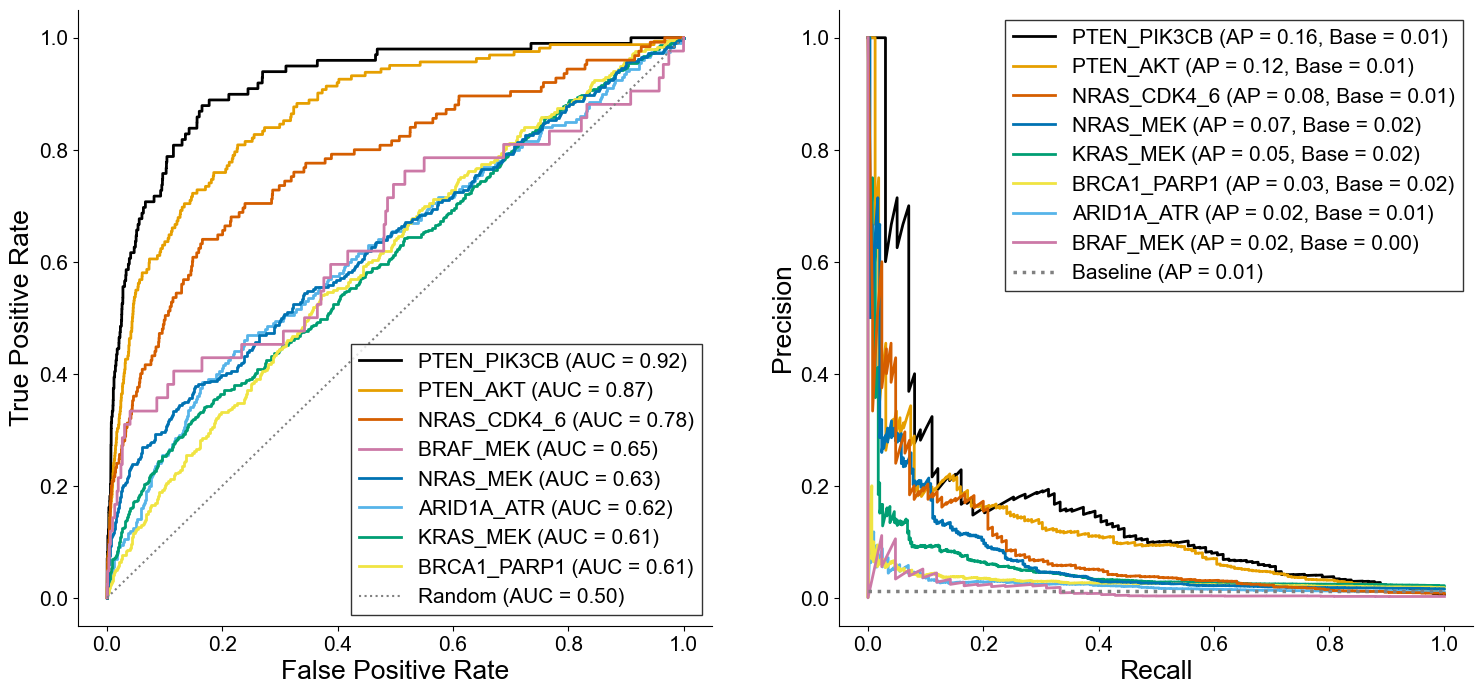

In [ ]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_curve, precision_recall_curve,
    average_precision_score, roc_auc_score
)

def compare_rf_models_by_slpair(
    df,
    slpair_list,
    feature_cols,
    target_col='Class_Processed'
):
    plt.figure(figsize=(18, 8))
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial'],
        'pdf.fonttype': 42,
        'ps.fonttype': 42
    })

    # Custom color palette
    color_palette = [
        "#000000", "#E69F00", "#56B4E9", "#009E73",
        "#F0E442", "#0072B2", "#D55E00", "#CC79A7"
    ]

    # Containers for sorting
    roc_handles, roc_labels, roc_aucs = [], [], []
    pr_handles, pr_labels, pr_aps = [], [], []

    for i, slpair in enumerate(slpair_list):
        test_mask = df['SL_Pair'] == slpair
        train_mask = ~test_mask

        train = df[train_mask]
        test = df[test_mask]

        X_train = train[feature_cols]
        X_test = test[feature_cols]
        y_train = train[target_col]
        y_test = test[target_col]

        if y_test.nunique() < 2:
            print(f"Skipping SL_Pair {slpair}: not enough class variation.")
            continue

        rf = RandomForestClassifier(
            n_estimators=1000,
            max_features=1,
            max_depth=15,
            min_samples_leaf=4,
            random_state=42
        )
        rf.fit(X_train, y_train)

        y_prob = rf.predict_proba(X_test)[:, 1]

        fpr, tpr, _ = roc_curve(y_test, y_prob)
        precision, recall, _ = precision_recall_curve(y_test, y_prob)
        roc_auc = roc_auc_score(y_test, y_prob)
        ap = average_precision_score(y_test, y_prob)
        baseline_precision = y_test.mean()

        color = color_palette[i % len(color_palette)]

        # ROC
        plt.subplot(1, 2, 1)
        (line_roc,) = plt.plot(
            fpr, tpr, color=color, linewidth=2,
            label=f"{slpair} (AUC = {roc_auc:.2f})"
        )
        roc_handles.append(line_roc)
        roc_labels.append(line_roc.get_label())
        roc_aucs.append(roc_auc)

        # PR
        plt.subplot(1, 2, 2)
        (line_pr,) = plt.plot(
            recall, precision, color=color, linewidth=2,
            label=f"{slpair} (AP = {ap:.2f}, Base = {baseline_precision:.2f})"
        )
        pr_handles.append(line_pr)
        pr_labels.append(line_pr.get_label())
        pr_aps.append(ap)

    # === ROC Formatting ===
    plt.subplot(1, 2, 1)
    line_rand, = plt.plot([0, 1], [0, 1], linestyle=':', color='gray',
                          label="Random (AUC = 0.50)", linewidth=1.5)

    sorted_items = sorted(zip(roc_handles, roc_labels, roc_aucs),
                          key=lambda x: x[2], reverse=True)
    if sorted_items:  # guard
        sorted_handles, sorted_labels, _ = zip(*sorted_items)
        plt.legend(list(sorted_handles) + [line_rand],
                   list(sorted_labels) + [line_rand.get_label()],
                   loc="lower right", fontsize=15,
                   frameon=True, edgecolor='black', fancybox=False)

    plt.xlabel("False Positive Rate", fontsize=19)
    plt.ylabel("True Positive Rate", fontsize=19)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.grid(False)
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # === PR Formatting ===
    plt.subplot(1, 2, 2)
    overall_baseline = df[target_col].mean()
    line_base = plt.hlines(overall_baseline, 0, 1, linestyle=':', color='gray',
                           label=f"Baseline (AP = {overall_baseline:.2f})", linewidth=2.5)

    sorted_items = sorted(zip(pr_handles, pr_labels, pr_aps),
                          key=lambda x: x[2], reverse=True)
    if sorted_items:  # guard
        sorted_handles, sorted_labels, _ = zip(*sorted_items)
        plt.legend(list(sorted_handles) + [line_base],
                   list(sorted_labels) + [line_base.get_label()],
                   loc="upper right", fontsize=15,
                   frameon=True, edgecolor='black', fancybox=False)

    plt.xlabel("Recall", fontsize=19)
    plt.ylabel("Precision", fontsize=19)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.grid(False)
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.savefig("results/5_ML_graphs/figure_S6_roc_pr_leave_one_slpair_out.png",
                dpi=600, bbox_inches='tight')
    plt.show()


# === Usage ===
feature_columns = main_unique.columns[-19:-1].tolist()

slpair_list = [
    'PTEN_PIK3CB', 'PTEN_AKT', 'ARID1A_ATR', 'KRAS_MEK',
    'BRCA1_PARP1', 'NRAS_MEK', 'NRAS_CDK4_6',
    'BRAF_MEK'
]

compare_rf_models_by_slpair(
    df=main_unique,
    slpair_list=slpair_list,
    feature_cols=feature_columns,
    target_col='Class_Processed'
)


# Knoll case study (Fig.6A)

In [3]:
knoll = pd.read_csv('knoll_case_study/data/knoll_withfeatures_dropna.csv')
knoll

,Screen,Query,Biomarker,Target,Class,hgnc_id_query,ensembl_gene_id_query,entrez_id_query,hgnc_id_biomarker,ensembl_gene_id_biomarker,...,EssentialityAverage,FET_SharedInteractors_Biomarker_BIOGRID,FET_SharedInteractors_Target_BIOGRID,FET_SharedInteractors_Biomarker_STRING,FET_SharedInteractors_Target_STRING,BIOGRIDPhysicalInteractionQueryBiomarker,BIOGRIDPhysicalInteractionQueryTarget,BiomarkerType,Essentiality_Percentage,Class_Processed
0,Knoll,CARM1,MTAP,PRMT5,Resistant,HGNC:23393,ENSG00000142453,10498.0,HGNC:7413,ENSG00000099810,...,0.231608,9.694669,46.889569,0.995129,81.936074,0,0,1,6.876061,1
1,Knoll,NME6,MTAP,PRMT5,Resistant,HGNC:20567,ENSG00000172113,10201.0,HGNC:7413,ENSG00000099810,...,0.166685,1.152364,1.334037,4.826142,0.268530,0,0,1,2.546689,1
2,Knoll,KDM1A,MTAP,PRMT5,Resistant,HGNC:29079,ENSG00000004487,23028.0,HGNC:7413,ENSG00000099810,...,0.095923,4.893714,50.448512,0.624721,108.909452,0,0,1,0.594228,1
3,Knoll,CAB39,MTAP,PRMT5,Resistant,HGNC:20292,ENSG00000135932,51719.0,HGNC:7413,ENSG00000099810,...,0.161837,4.934157,4.961528,0.000000,1.989841,0,0,1,10.016978,1
4,Knoll,NRDC,MTAP,PRMT5,Resistant,HGNC:7995,ENSG00000078618,4898.0,HGNC:7413,ENSG00000099810,...,0.396905,7.242344,10.174983,0.651788,2.393155,0,0,1,12.818336,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4534,Knoll,MAPK1,MTAP,PRMT5,not_resistant,HGNC:6871,ENSG00000100030,5594.0,HGNC:7413,ENSG00000099810,...,1.209159,19.589239,59.638015,0.617685,21.718543,0,0,1,9.168081,0
4535,Knoll,ZFP36L1,MTAP,PRMT5,not_resistant,HGNC:1107,ENSG00000185650,677.0,HGNC:7413,ENSG00000099810,...,0.402389,5.871749,25.285584,0.665267,33.811867,0,0,1,14.346350,0
4536,Knoll,RAF1,MTAP,PRMT5,not_resistant,HGNC:9829,ENSG00000132155,5894.0,HGNC:7413,ENSG00000099810,...,0.127330,0.299575,15.704089,0.000000,40.653705,0,0,1,7.894737,0
4537,Knoll,PTEN,MTAP,PRMT5,not_resistant,HGNC:9588,ENSG00000171862,5728.0,HGNC:7413,ENSG00000099810,...,0.273344,12.101504,26.709477,0.652988,12.724496,0,0,1,0.679117,0


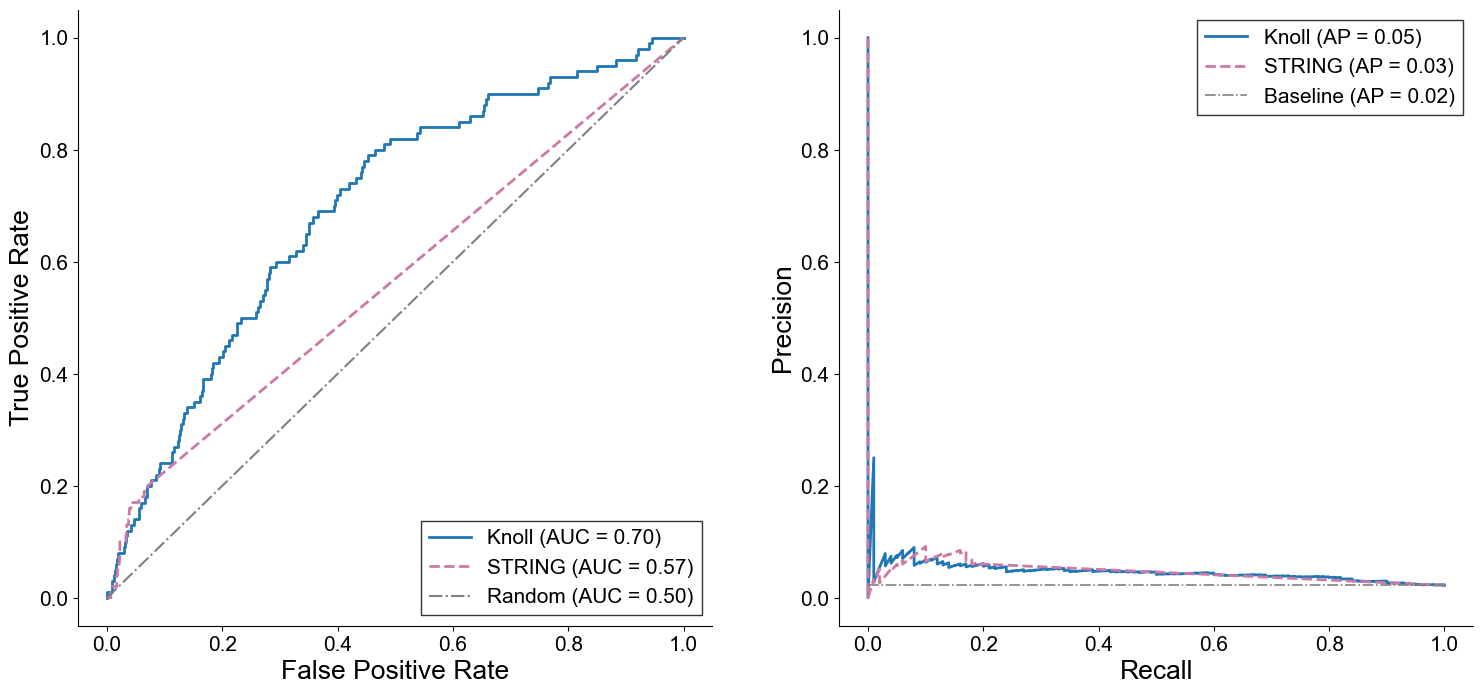

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_curve, precision_recall_curve,
    average_precision_score, roc_auc_score
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# === Font Setup ===
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

# === Validation Data
X_val = knoll.iloc[:, -19:-1].values
y_val = knoll['Class_Processed'].values
x_string = knoll['StringInteractionWithBiomarker'].values

def evaluate_model(name, X_train, y_train):
    rf = RandomForestClassifier(
        n_estimators=1000,
        max_features=1,
        max_depth=15,
        min_samples_leaf=4,
        random_state=42
    )
    rf.fit(X_train, y_train)
    y_prob = rf.predict_proba(X_val)[:, 1]

    fpr, tpr, _ = roc_curve(y_val, y_prob)
    precision, recall, _ = precision_recall_curve(y_val, y_prob)
    auc = roc_auc_score(y_val, y_prob)
    ap = average_precision_score(y_val, y_prob)

    fpr_str = tpr_str = auc_str = ap_str = None
    precision_str = recall_str = None

    if name == "Knoll":
        fpr_str, tpr_str, _ = roc_curve(y_val, x_string)
        precision_str, recall_str, _ = precision_recall_curve(y_val, x_string)
        auc_str = roc_auc_score(y_val, x_string)
        ap_str = average_precision_score(y_val, x_string)

    return {
        'name': name,
        'fpr': fpr, 'tpr': tpr, 'auc': auc,
        'precision': precision, 'recall': recall, 'ap': ap,
        'fpr_str': fpr_str, 'tpr_str': tpr_str, 'auc_str': auc_str,
        'precision_str': precision_str, 'recall_str': recall_str, 'ap_str': ap_str,
        'model': rf
    }

# === Model Evaluations
X = main_unique.iloc[:, -19:-1].values
y = main_unique['Class_Processed'].values
results_random = evaluate_model("Knoll", X, y)

# Extract trained RF model
rf = results_random["model"]   # ✅ get model object

# === Create DataFrame for empirical top-k analysis ===
df_pred = pd.DataFrame({
    "Gene": knoll["Query"],    # ensure this column exists
    "Score": rf.predict_proba(X_val)[:, 1],  # now works fine
    "Label": y_val
})
df_pred = df_pred[["Gene", "Score", "Label"]]
df_pred.to_csv("results/5_ML_graphs/knoll_dataset_model_predictions_score_causal.csv", index=False)

# === Simulate random classifier predictions ===
np.random.seed(42)
df_random = pd.DataFrame({
    "Gene": knoll["Query"],
    "Score": np.random.rand(len(knoll)),  # random scores between 0 and 1
    "Label": y_val
})
df_random = df_random[["Gene", "Score", "Label"]]
df_random.to_csv("results/5_ML_graphs/knoll_dataset_random_classifier_predictions.csv", index=False)

# === Plotting
fig, axs = plt.subplots(1, 2, figsize=(18, 8))

# --- ROC Curve ---
ax = axs[0]
handles, labels, aucs = [], [], []

for res in [results_random]:
    line, = ax.plot(res['fpr'], res['tpr'], linewidth=2,
                    label=f"{res['name']} (AUC = {res['auc']:.2f})")
    handles.append(line); labels.append(line.get_label()); aucs.append(res['auc'])

    if res['fpr_str'] is not None:
        line, = ax.plot(res['fpr_str'], res['tpr_str'], linestyle='--', linewidth=2, color='#CC79A7',
                        label=f"STRING (AUC = {res['auc_str']:.2f})")
        handles.append(line); labels.append(line.get_label()); aucs.append(res['auc_str'])

# Add random baseline
line_rand, = ax.plot([0, 1], [0, 1], color='gray', linestyle='-.', linewidth=1.5,
                     label="Random (AUC = 0.50)")

# Sort by AUC descending, Random last
sorted_items = sorted(zip(handles, labels, aucs), key=lambda x: x[2], reverse=True)
sorted_handles, sorted_labels, _ = zip(*sorted_items)
ax.legend(list(sorted_handles) + [line_rand],
          list(sorted_labels) + [line_rand.get_label()],
          loc='lower right', fontsize=15, frameon=True,
          edgecolor='black', fancybox=False)

ax.set_xlabel("False Positive Rate", fontsize=19)
ax.set_ylabel("True Positive Rate", fontsize=19)
ax.tick_params(axis='both', labelsize=15)
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- PR Curve ---
ax = axs[1]
handles, labels, aps = [], [], []
baseline_precision = np.mean(y_val)

for res in [results_random]:
    line, = ax.plot(res['recall'], res['precision'], linewidth=2,
                    label=f"{res['name']} (AP = {res['ap']:.2f})")
    handles.append(line); labels.append(line.get_label()); aps.append(res['ap'])

    if res['precision_str'] is not None:
        line, = ax.plot(res['recall_str'], res['precision_str'], linestyle='--', linewidth=2, color='#CC79A7',
                        label=f"STRING (AP = {res['ap_str']:.2f})")
        handles.append(line); labels.append(line.get_label()); aps.append(res['ap_str'])

# Add baseline
line_base = ax.hlines(baseline_precision, 0, 1, linestyle='-.', color='gray',
                      label=f"Baseline (AP = {baseline_precision:.2f})", linewidth=1.2)

# Sort by AP descending, Baseline last
sorted_items = sorted(zip(handles, labels, aps), key=lambda x: x[2], reverse=True)
sorted_handles, sorted_labels, _ = zip(*sorted_items)
ax.legend(list(sorted_handles) + [line_base],
          list(sorted_labels) + [line_base.get_label()],
          loc='upper right', fontsize=15, frameon=True,
          edgecolor='black', fancybox=False)

ax.set_xlabel("Recall", fontsize=19)
ax.set_ylabel("Precision", fontsize=19)
ax.tick_params(axis='both', labelsize=15)
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# === Final Styling
plt.savefig("results/5_ML_graphs/knoll_dataset_model_notest_split_no_coexpression_string_biomarker.png",
            dpi=600, bbox_inches='tight')
plt.show()
